In [ ]:
import sys
from astropy import units as un, constants as cons
from astropy.cosmology import Planck18 as cosmo
import numpy as np
from matplotlib import pyplot as plt
import cmasher as cmr
from astropy.visualization import quantity_support
quantity_support()

sys.path.append('../pysrc/')
from latexify import latexify
import solve_ode as CF
import HaloPotential_new as Halo
import WiersmaCooling as Cool

import warnings
warnings.simplefilter("ignore", RuntimeWarning)

import importlib # for testing : importlib.reload(module)

In [4]:
# Set Cosmology
rho_crit = cosmo.critical_density0
rho_mean = cosmo.Om0*rho_crit
delta_c =  18 * np.pi**2 + 82 * (cosmo.Om0 - 1) - 39 * (cosmo.Om0 - 1)**2 # Bryan & Norman 98
mu = 0.62 # mean molecular weight

# Helper function for dervied values
def calc_r_vir(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / delta_c / rho_crit, 1/3)
    return r_vir.to('kpc')

def calc_r_200_c(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / 200 / rho_crit, 1/3)
    return r_vir.to('kpc')
    
def calc_r_200_m(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / 200 / rho_mean, 1/3)
    return r_vir.to('kpc')

def calc_T_vir(M_vir):
    r_vir = calc_r_vir(M_vir)
    vc = np.sqrt(cons.G * M_vir / r_vir)
    temp = mu*cons.m_p*vc**2/cons.k_B/2
    return temp.to('K')

def calc_concentration(M_vir):
    h = cosmo.H0.value/100
    M_ref = 1e12/h * un.Msun
    log_c = 0.905 - 0.101*np.log10(M_vir/M_ref)
    return np.power(10, log_c)

def circular_temp(vc):
    temp = 0.6*mu*cons.m_p*vc**2/cons.k_B
    return temp.to('K')

# Set Halo Parameters
M_vir = 1e11 * un.Msun
r_vir = calc_r_vir(M_vir)
T_vir = calc_T_vir(M_vir)
c_vir = calc_concentration(M_vir) # Concentration parameter
r_200_m = calc_r_200_m(M_vir)
r_200_c = calc_r_200_c(M_vir)
M_gal = 1e10 * un.Msun # Greco et al 2012 for M82
r_gal = 0.015*r_200_c # Kravtsoc 2013 expression for stellar half-mass radius
z_gal = 0.15 * un.kpc # Lim et al 2013 for M82
      
print("Halo Mass: ",M_vir)
print("Virial Radius: ", r_vir)
print("Virial Temperature: ", T_vir)
print("Concentration Parameter: ", c_vir)
print("R200m: ", r_200_m)
print("R200c: ", r_200_c)
print("Disk Mass", M_gal)
print("Disk Scale Radius", r_gal)
print("Disk Scale Height", z_gal)

# Set Halo Potential
nfw = Halo.NFWPotential(M_vir, r_vir, c_vir)
plummer = Halo.PlummerPotential(M_gal, r_gal)
outer = Halo.OuterHaloPotential(rho_mean, r_200_m)
combined = Halo.CombinedPotential(M_vir, r_vir, c_vir, M_gal, r_gal, rho_mean, r_200_m)

Halo Mass:  100000000000.0 solMass
Virial Radius:  122.40315626626357 kpc
Virial Temperature:  131960.7175211719 K
Concentration Parameter:  10.54718269190388
R200m:  144.76736317842207 kpc
R200c:  97.94126310709676 kpc
Disk Mass 10000000000.0 solMass
Disk Scale Radius 1.4691189466064514 kpc
Disk Scale Height 0.15 kpc


In [5]:
# Set Cooling
cooling = Cool.Wiersma_Cooling(Z2Zsun=1/3,z=0)

In [10]:
max_step = 0.01                          #lowest resolution of solution in ln(r)
R_min    = 1*un.kpc                      #inner radius of supersonic part of solution
R_max    = 2.*combined.r_vir             #outer radius of integration
R_sonics  = np.linspace(1,30,10)*un.kpc  #sonic radii
transsonic_solutions = []
for R_sonic in R_sonics:
    print('R_sonic = %s'%R_sonic)
    transsonic_solutions.append(CF.shoot_from_R_sonic(combined,
                                                      cooling,
                                                      R_sonic,
                                                      R_max,
                                                      R_min,
                                                      max_step=max_step,
                                                      verbose=False))
                    

R_sonic = 1.0 kpc
R_sonic = 4.222222222222222 kpc
No result reached R_max. Set return_all_results=True to check intermediate solutions.
R_sonic = 7.444444444444445 kpc
No result reached R_max. Set return_all_results=True to check intermediate solutions.
R_sonic = 10.666666666666668 kpc
R_sonic = 13.88888888888889 kpc
R_sonic = 17.11111111111111 kpc
R_sonic = 20.333333333333336 kpc
R_sonic = 23.555555555555557 kpc
R_sonic = 26.77777777777778 kpc
R_sonic = 30.0 kpc


0.4949729265576879 solMass / yr
0.6691689827648066 solMass / yr
0.7191816942631598 solMass / yr
0.7741370386709253 solMass / yr
0.8241212234235759 solMass / yr
0.8728892158063871 solMass / yr
0.9174899841775276 solMass / yr
0.9543674559455188 solMass / yr


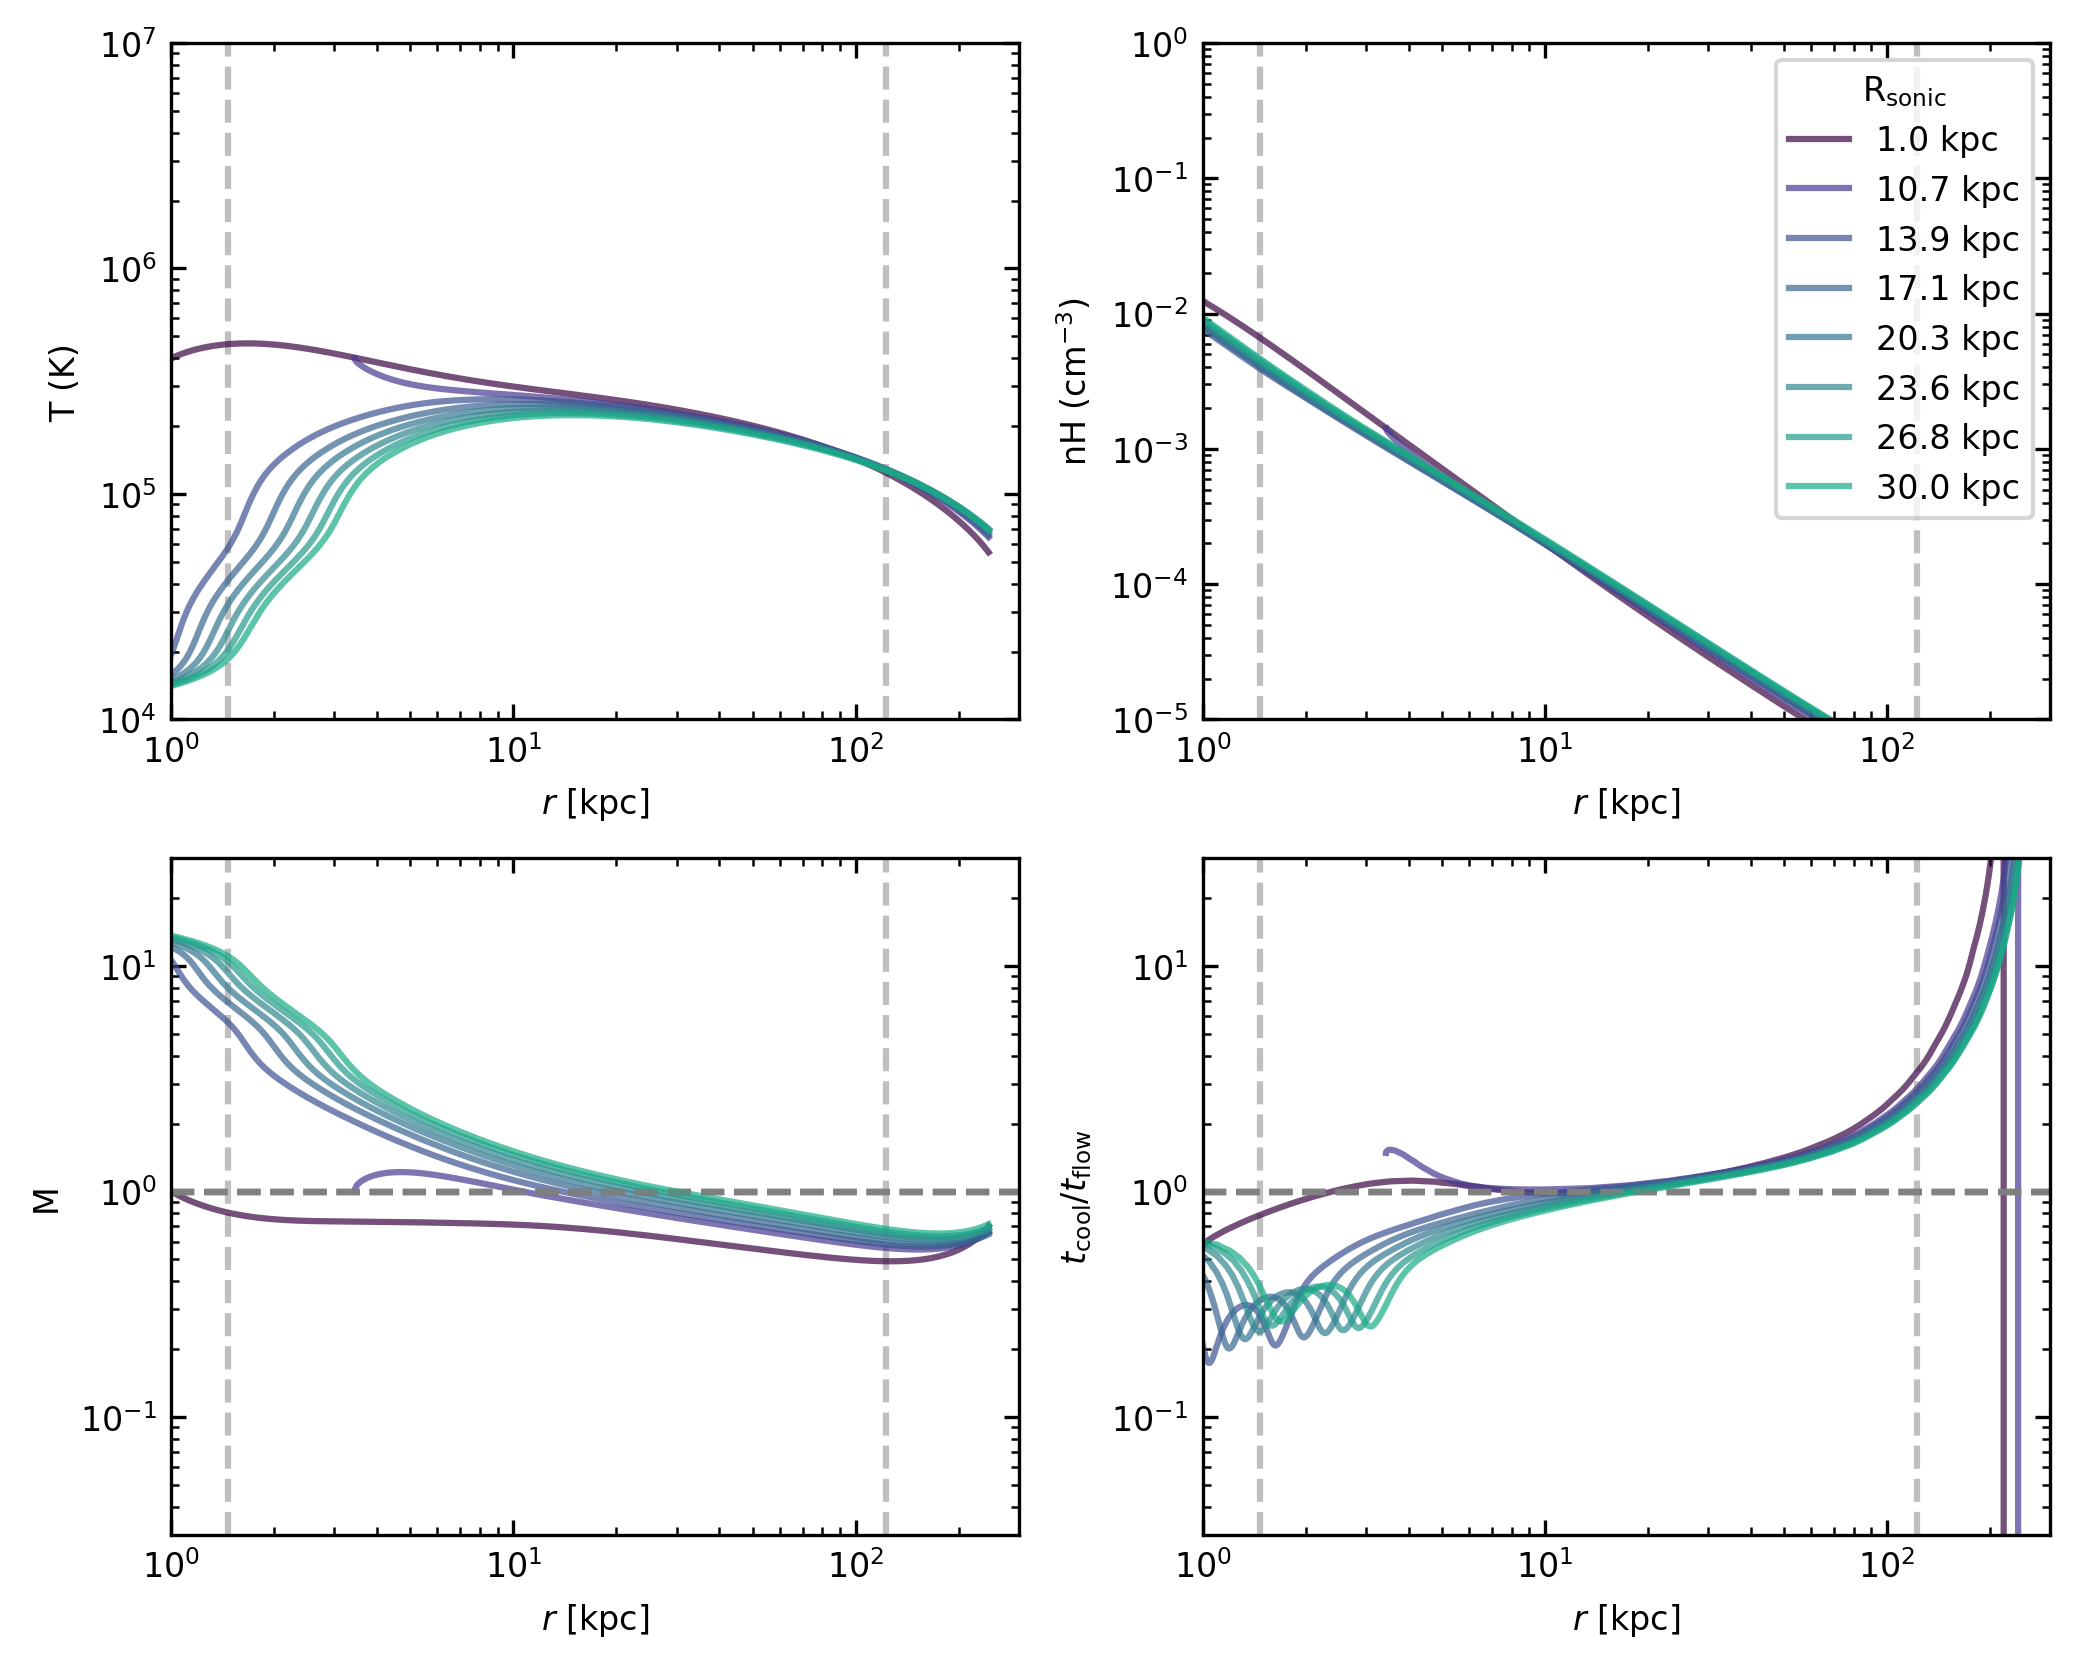

In [12]:
latexify(columns=2)
fig, axs = plt.subplots(2, 2)

for ax in axs.flatten():
    ax.set_xlabel(r'$r$ [kpc]')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(top=True, right=True, which="both", direction='in')
    ax.set_xlim(1,300)

    ax.axvline(r_gal,c='.5',ls='--',alpha=0.5)
    ax.axvline(r_vir,c='.5',ls='--',alpha=0.5)

colors = cmr.lavender(np.linspace(0.2,0.8,len(transsonic_solutions)))
for i in range(len(transsonic_solutions)):
    res = transsonic_solutions[i]
    if res is not None:
        axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color=colors[i])
        axs[0, 0].set_ylabel(r'T (K)')
        axs[0, 0].set_ylim(1e4,1e7)
        
        axs[0, 1].plot(res.Rs, res.nHs, alpha=0.7, color=colors[i], label=f'{R_sonics[i].value:.1f} kpc')
        axs[0, 1].set_ylabel(r'nH (cm$^{-3}$)')
        axs[0, 1].set_ylim(1e-5,1)
        
        axs[1, 0].plot(res.Rs, res.Ms, alpha=0.7, color=colors[i])
        axs[1, 0].set_ylabel(r'M')
        axs[1, 0].set_ylim(0.03,30)
        axs[1, 0].axhline(1.,c='.5',ls='--',alpha=0.5)
        
        axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color=colors[i])
        axs[1, 1].set_ylabel(r'$t_{\rm cool}/t_{\rm flow}$')
        axs[1, 1].set_ylim(0.03,30)
        axs[1, 1].axhline(1.,c='.5',ls='--',alpha=0.5)

        print(res.mass_flow_rate)

axs[0, 1].legend(frameon=True, loc='upper right', title=r'R$_{\rm sonic}$', handlelength=1.8)
plt.tight_layout()
# plt.savefig('./plots/cf_sols.pdf',dpi=150)
plt.show()

In [8]:
max_step = 0.1                             # lowest resolution of solution in ln(r)
R_circ   = 1 * un.kpc                      # circularization radius
R_max    = 500 * un.kpc                    # outer radius of integration
Mdots  = [1.0]*un.Msun/un.yr  #np.logspace(-2,-1,10)*un.Msun/un.yr  # mass inflow rates
stalled_solutions = []
for Mdot in Mdots:
    print('Mdot = %s'%Mdot)
    stalled_solutions.append(CF.shoot_from_R_circ(combined,
                                                  cooling,
                                                  R_circ,
                                                  Mdot,
                                                  R_max,
                                                  v0 = 1*un.km/un.s,
                                                  max_step=max_step,
                                                  verbose=True))

Mdot = 1.0 solMass / yr
Integrating with log T(R_circ) = 4.50 ... Stop reason: Unbound (Maximum r = 1 kpc)
Integrating with log T(R_circ) = 4.25 ... Stop reason: Unbound (Maximum r = 1 kpc)
Integrating with log T(R_circ) = 4.12 ... Stop reason: Unbound (Maximum r = 1 kpc)
Integrating with log T(R_circ) = 4.06 ... Stop reason: Unbound (Maximum r = 1 kpc)
Integrating with log T(R_circ) = 4.03 ... Stop reason: Unbound (Maximum r = 2 kpc)
Integrating with log T(R_circ) = 4.02 ... Stop reason: Unbound (Maximum r = 2 kpc)
Integrating with log T(R_circ) = 4.01 ... Stop reason: Unbound (Maximum r = 2 kpc)
Integrating with log T(R_circ) = 4.00 ... Stop reason: Unbound (Maximum r = 2 kpc)
Integrating with log T(R_circ) = 4.00 ... Stop reason: Unbound (Maximum r = 2 kpc)
Integrating with log T(R_circ) = 4.00 ... Stop reason: Unbound (Maximum r = 2 kpc)
Integrating with log T(R_circ) = 4.00 ... Stop reason: Unbound (Maximum r = 2 kpc)
Integrating with log T(R_circ) = 4.00 ... Stop reason: Unbound 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


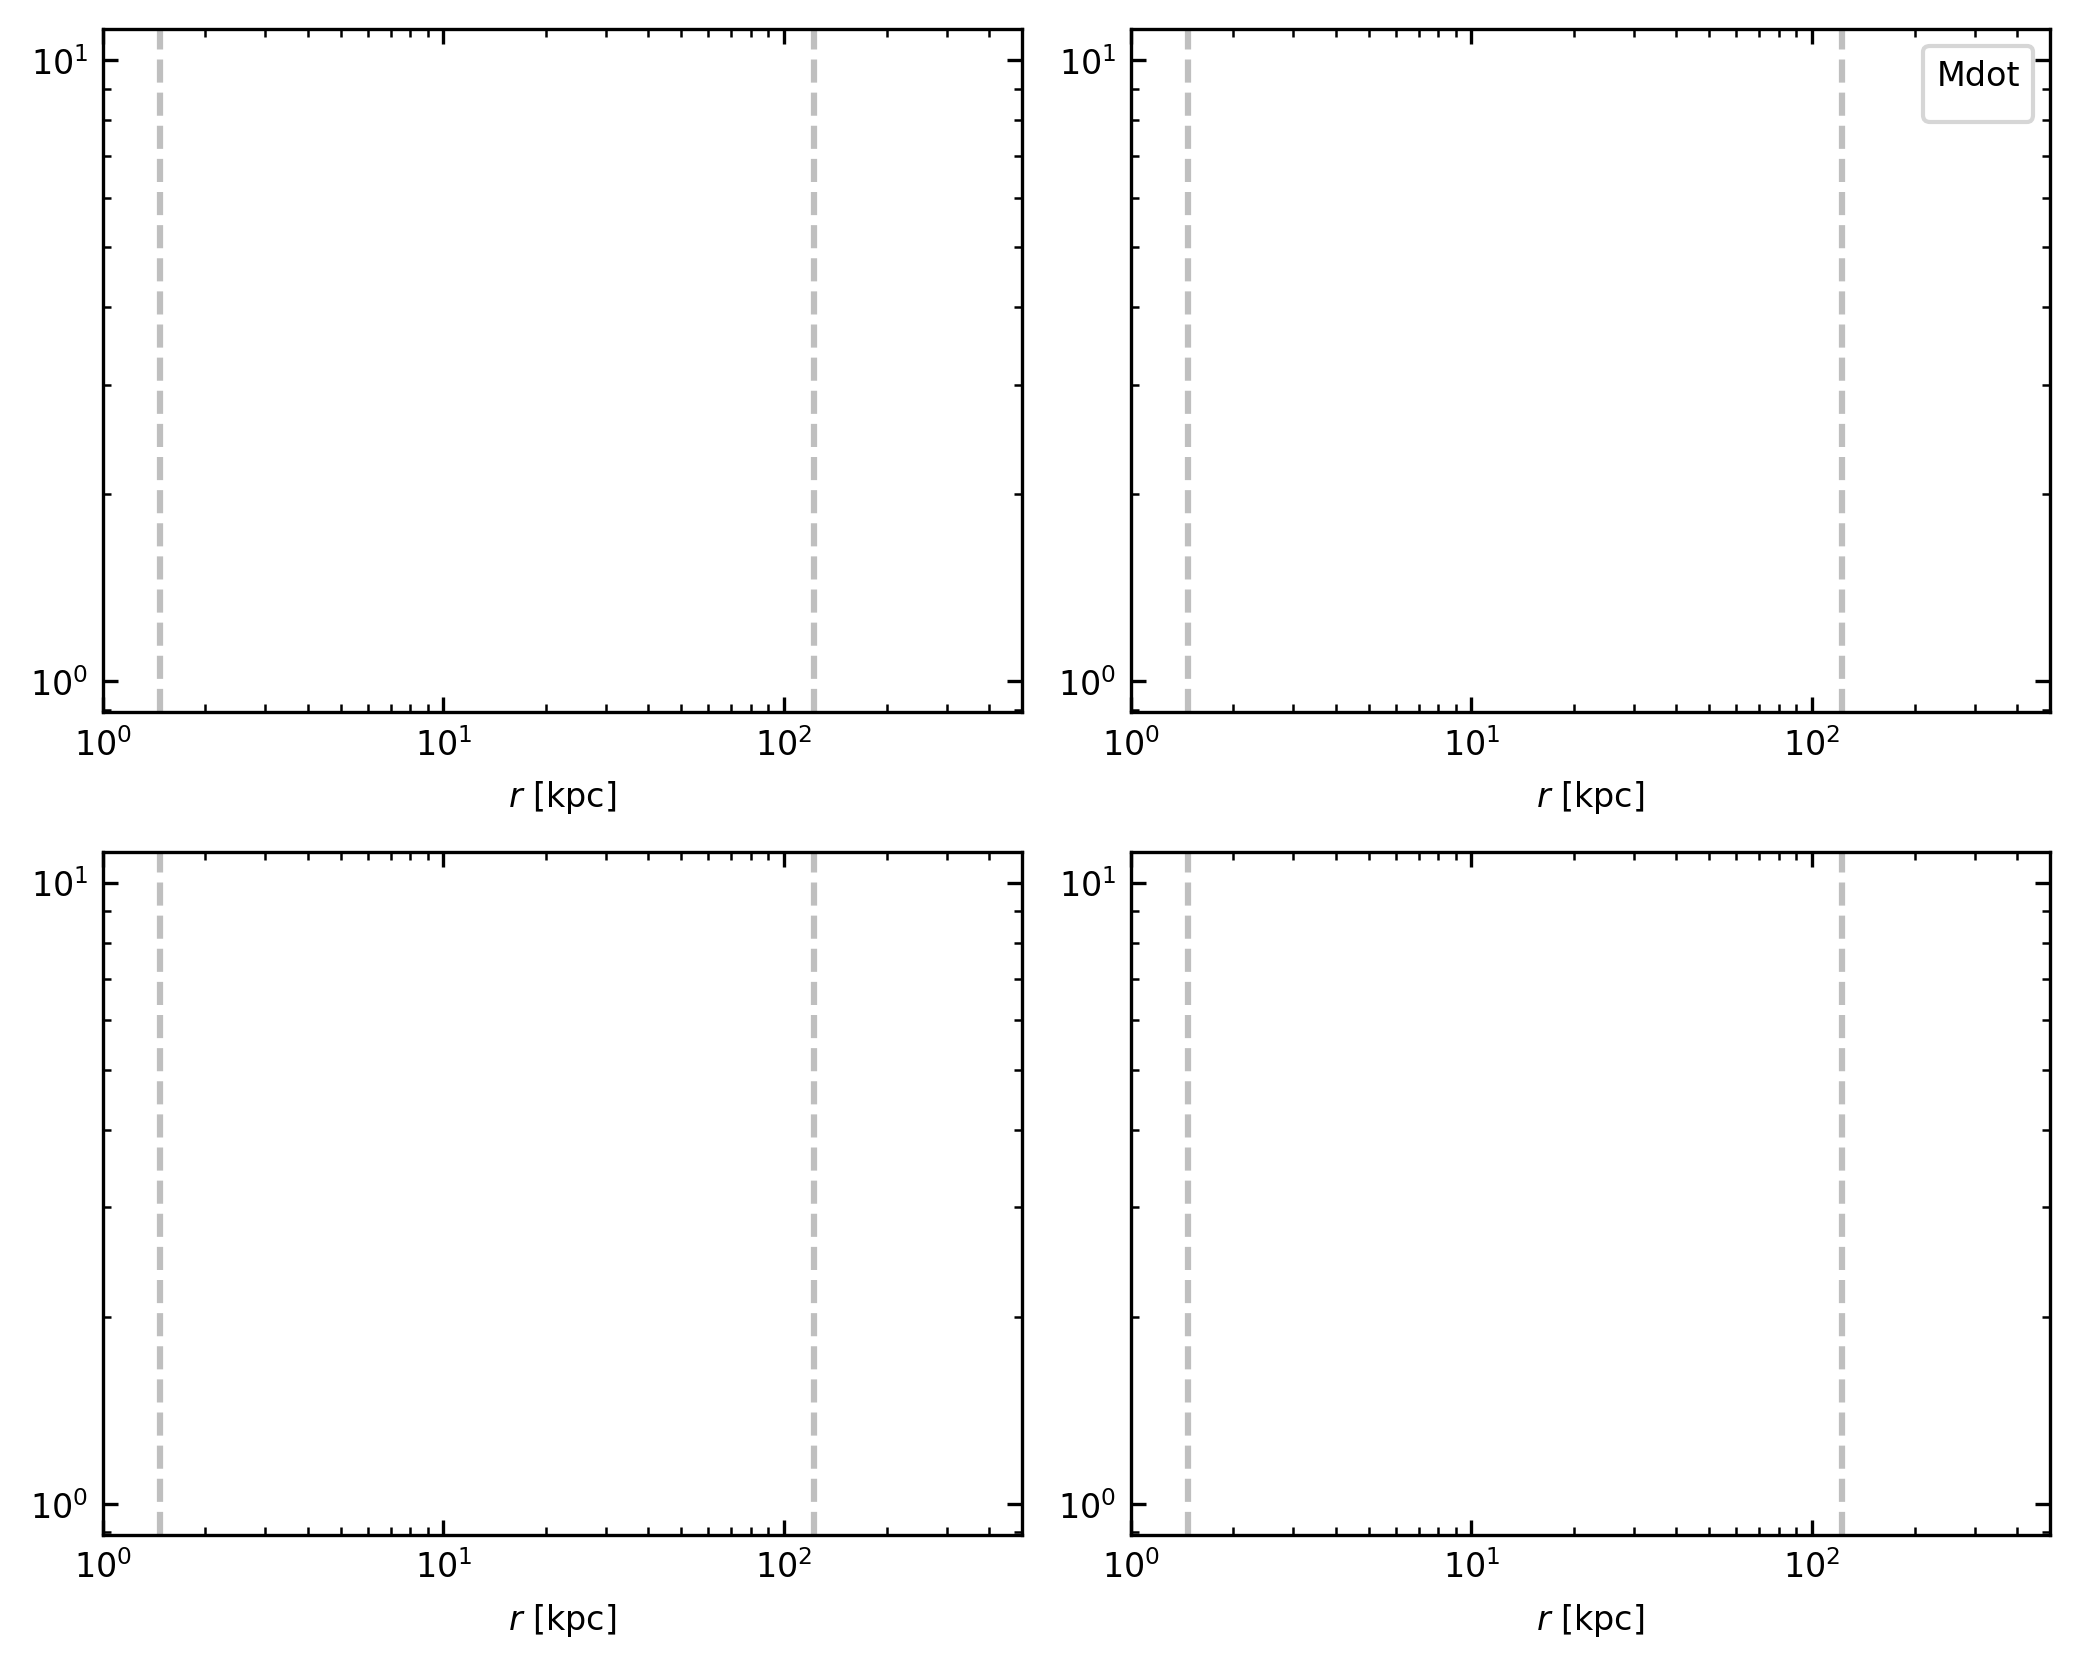

In [9]:
latexify(columns=2)
fig, axs = plt.subplots(2, 2)

for ax in axs.flatten():
    ax.set_xlabel(r'$r$ [kpc]')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(top=True, right=True, which="both", direction='in')
    ax.set_xlim(1,500)

    ax.axvline(r_gal,c='.5',ls='--',alpha=0.5)
    ax.axvline(r_vir,c='.5',ls='--',alpha=0.5)

# sols = list(stalled_solutions[0].values())
colors = cmr.lavender(np.linspace(0.2,0.8,len(stalled_solutions)))
for i in range(len(stalled_solutions)):
    res = stalled_solutions[i]
    if res is not None:
        axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color=colors[i])
        axs[0, 0].set_ylabel(r'T (K)')
        axs[0, 0].set_ylim(1e4,1e7)
        
        axs[0, 1].plot(res.Rs, res.nHs, alpha=0.7, color=colors[i], label=f'{Mdots[i]:.3f}')
        axs[0, 1].set_ylabel(r'nH (cm$^{-3}$)')
        axs[0, 1].set_ylim(1e-5,1)
        
        axs[1, 0].plot(res.Rs, res.Ms, alpha=0.7, color=colors[i])
        axs[1, 0].set_ylabel(r'M')
        axs[1, 0].set_ylim(0.03,30)
        axs[1, 0].axhline(1.,c='.5',ls='--',alpha=0.5)
        
        axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color=colors[i])
        axs[1, 1].set_ylabel(r'$t_{\rm cool}/t_{\rm flow}$')
        axs[1, 1].set_ylim(0.03,30)
        axs[1, 1].axhline(1.,c='.5',ls='--',alpha=0.5)

axs[0, 1].legend(frameon=True, loc='upper right', title=r'Mdot', handlelength=1.8)
plt.tight_layout()
plt.show()